# Exploratory Data Analysis Section

This notebook will use PyAthena to query a AWS Glue database table that contains the raw information then perform Exploratory Data Analysis.

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

from windrose import WindroseAxes

In [2]:
# read in the csv data file into a pandas dataframe
raw_df = pd.read_csv("../2_raw_data/raw_merged/raw_merged_data.csv")

In [3]:
# Get shape of the data
raw_df.shape

(185600, 21)

In [4]:
# Get a list of the column names
raw_df.columns

Index(['FL_DATE', 'CRS_DEP_TIME', 'DEP_TIME', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_FL_NUM', 'DEST', 'DEP_DEL15', 'CANCELLED',
       'CANCELLATION_CODE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
       'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'wind_dir_degrees',
       'wind_speed_kt', 'wind_gust_kt', 'visibility_statute_mi',
       'temperature_c', 'dewpoint_c', 'altimeter_hpa'],
      dtype='object')

In [5]:
# get information on the df
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185600 entries, 0 to 185599
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   FL_DATE                185600 non-null  object 
 1   CRS_DEP_TIME           185600 non-null  object 
 2   DEP_TIME               183548 non-null  object 
 3   OP_UNIQUE_CARRIER      185600 non-null  object 
 4   OP_CARRIER_FL_NUM      185600 non-null  int64  
 5   DEST                   185600 non-null  object 
 6   DEP_DEL15              185600 non-null  int64  
 7   CANCELLED              185600 non-null  int64  
 8   CANCELLATION_CODE      2118 non-null    object 
 9   CARRIER_DELAY          185600 non-null  int64  
 10  WEATHER_DELAY          185600 non-null  int64  
 11  NAS_DELAY              185600 non-null  int64  
 12  SECURITY_DELAY         185600 non-null  int64  
 13  LATE_AIRCRAFT_DELAY    185600 non-null  int64  
 14  wind_dir_degrees       170031 non-nu

In [6]:
# get number of nulls in each column
raw_df.isnull().sum()

FL_DATE                       0
CRS_DEP_TIME                  0
DEP_TIME                   2052
OP_UNIQUE_CARRIER             0
OP_CARRIER_FL_NUM             0
DEST                          0
DEP_DEL15                     0
CANCELLED                     0
CANCELLATION_CODE        183482
CARRIER_DELAY                 0
WEATHER_DELAY                 0
NAS_DELAY                     0
SECURITY_DELAY                0
LATE_AIRCRAFT_DELAY           0
wind_dir_degrees          15569
wind_speed_kt                 0
wind_gust_kt                  0
visibility_statute_mi         0
temperature_c                 0
dewpoint_c                    0
altimeter_hpa                 0
dtype: int64

In [7]:
# get summary statistics of the dataframe
raw_df.describe()

,OP_CARRIER_FL_NUM,DEP_DEL15,CANCELLED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,wind_dir_degrees,wind_speed_kt,wind_gust_kt,visibility_statute_mi,temperature_c,dewpoint_c,altimeter_hpa
count,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,170031.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000
mean,1992.292236,0.095264,0.011412,3.595609,0.565388,3.030501,0.022328,6.407473,210.329940,5.555167,1.506606,9.548665,18.208988,11.916069,29.999487
std,1281.470818,0.293580,0.106214,33.489037,12.527305,15.422100,1.125169,31.559910,118.023751,3.311657,5.157662,1.415645,4.018744,5.143698,0.104090
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,-17.800000,-17.800000,29.450000
25%,894.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,3.000000,0.000000,10.000000,15.600000,8.900000,29.930000
50%,1939.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,270.000000,6.000000,0.000000,10.000000,18.300000,12.800000,29.990000
75%,2924.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,8.000000,0.000000,10.000000,21.100000,16.100000,30.070000
max,8784.000000,1.000000,1.000000,3300.000000,1171.000000,1431.000000,276.000000,2100.000000,360.000000,22.000000,42.000000,10.000000,34.400000,22.800000,30.360000


## Target Variable Exploration of Delayed and Cancelled flights

In [8]:
# count the number of DEP_DEL15 values
raw_df['DEP_DEL15'].value_counts()

DEP_DEL15
0    167919
1     17681
Name: count, dtype: int64

In [9]:
# get unique values of DEP_DEL15
raw_df['DEP_DEL15'].unique()

array([0, 1], dtype=int64)

In [10]:
# count the number of CANCELLED values
raw_df['CANCELLED'].value_counts()

CANCELLED
0    183482
1      2118
Name: count, dtype: int64

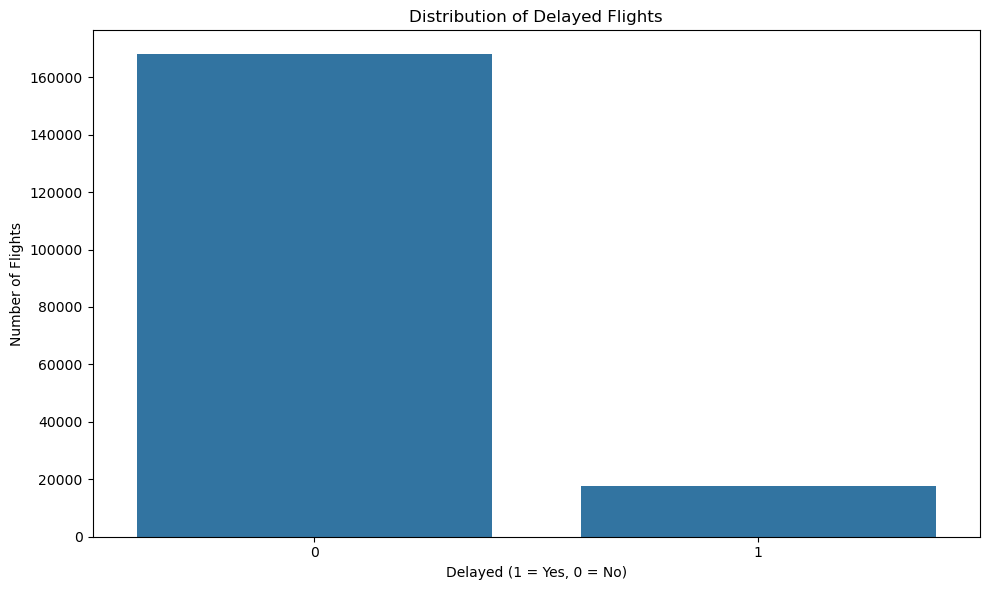

In [11]:
# visualize the distribution of delayed flights
plt.figure(figsize=(10,6))
sns.countplot(data=raw_df, x='DEP_DEL15')
plt.title('Distribution of Delayed Flights')
plt.xlabel('Delayed (1 = Yes, 0 = No)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

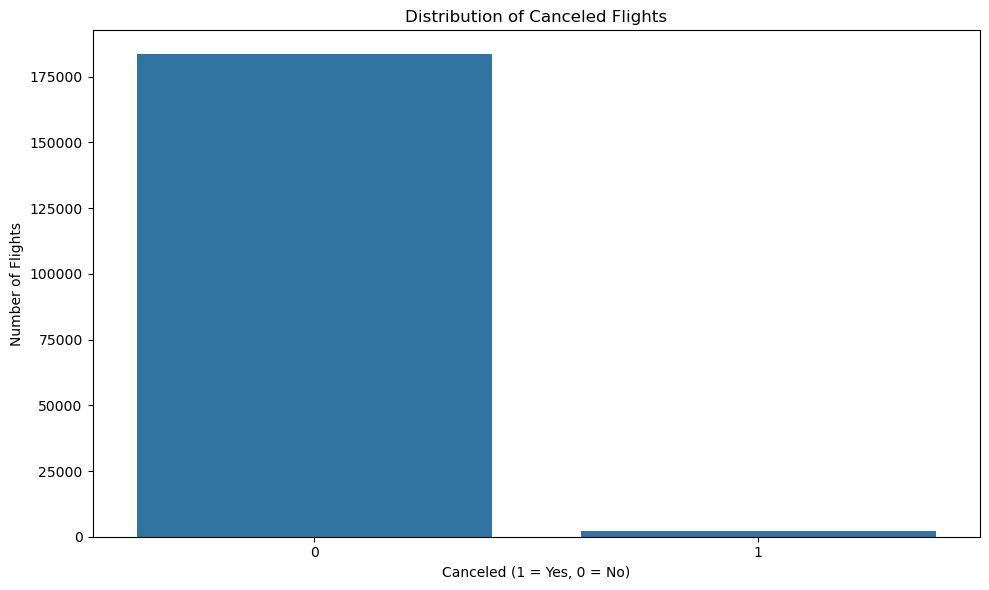

In [12]:
# visualize distribution of canceled flights
plt.figure(figsize=(10,6))
sns.countplot(data=raw_df, x='CANCELLED')
plt.title('Distribution of Canceled Flights')
plt.xlabel('Canceled (1 = Yes, 0 = No)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

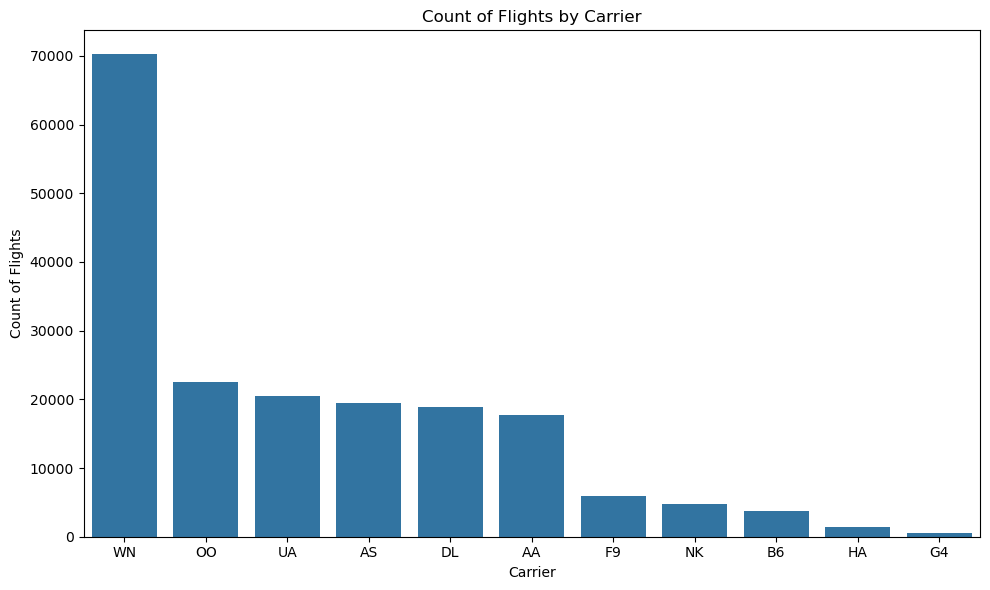

In [13]:
# explore the distribution of carriers and flights
# get count of flights by airline
carrier_counts = raw_df['OP_UNIQUE_CARRIER'].value_counts().reset_index()
carrier_counts.columns = ['Carrier', 'Count of Flights']

# plot the count of flights by airline
plt.figure(figsize=(10,6))
sns.barplot(data=carrier_counts, x='Carrier', y='Count of Flights')
plt.title('Count of Flights by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Count of Flights')
plt.tight_layout()
plt.show()

In [14]:
# create new category in dataframe for eda
raw_eda_df = raw_df.copy()

In [15]:
"""
Funciton that will categorize Canceled, Delayed, and On-Time flights
"""
def classify_fl_status(row):
    if row['CANCELLED'] == 1:
        return 'Cancelled'
    elif row['DEP_DEL15'] == 1:
        return 'Delayed'
    elif row['DEP_DEL15'] == 0:
        return 'On-Time'
    else:
        return 'Unknown'

  Flight_Status   count  Percentage
0       On-Time  165811   89.337823
1       Delayed   17671    9.521013
2     Cancelled    2118    1.141164


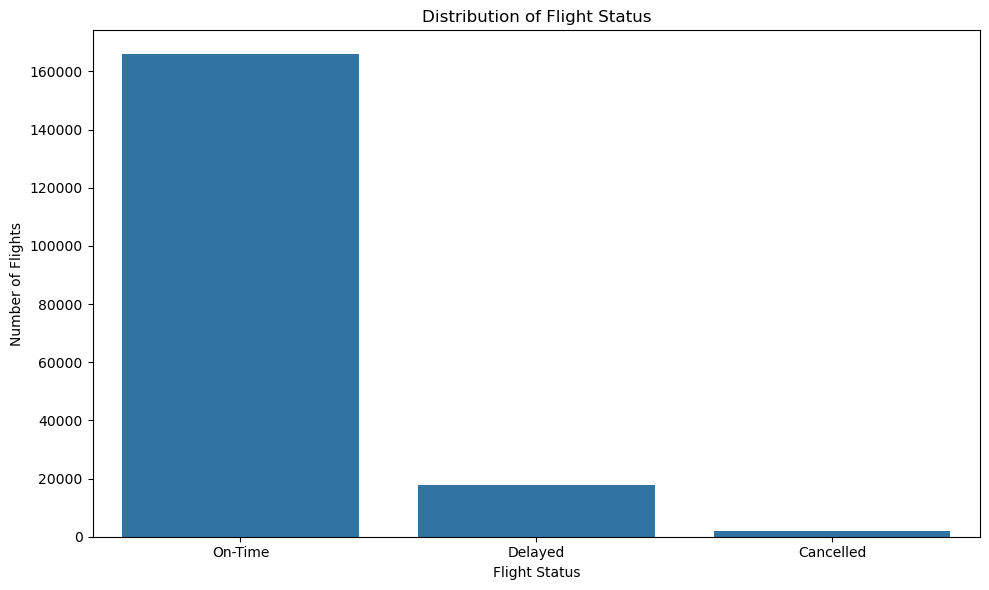

In [16]:
# create the new column in the dataframe by applying the function
raw_eda_df['Flight_Status'] = raw_eda_df.apply(classify_fl_status, axis=1)

# get the counts of the flight status column
fl_status_counts = raw_eda_df['Flight_Status'].value_counts().reset_index()
# print(fl_status_counts)

# print the percentage of each flight status
fl_status_counts['Percentage'] = (fl_status_counts['count'] / fl_status_counts['count'].sum()) * 100
print(fl_status_counts)

# visualize the distribution of flight status
plt.figure(figsize=(10,6))
sns.countplot(data=raw_eda_df, x='Flight_Status')
plt.title('Distribution of Flight Status')
plt.xlabel('Flight Status')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

Flight_Status  Cancelled  Delayed  On-Time
Carrier                                   
AA                   192     1483    16001
AS                   326     1495    17581
B6                    29      634     3060
DL                   141     1211    17482
F9                   133      826     4971
G4                     9      158      425
HA                     8      173     1253
NK                    87      481     4263
OO                   139     1453    20938
UA                   320     1378    18735
WN                   734     8379    61102


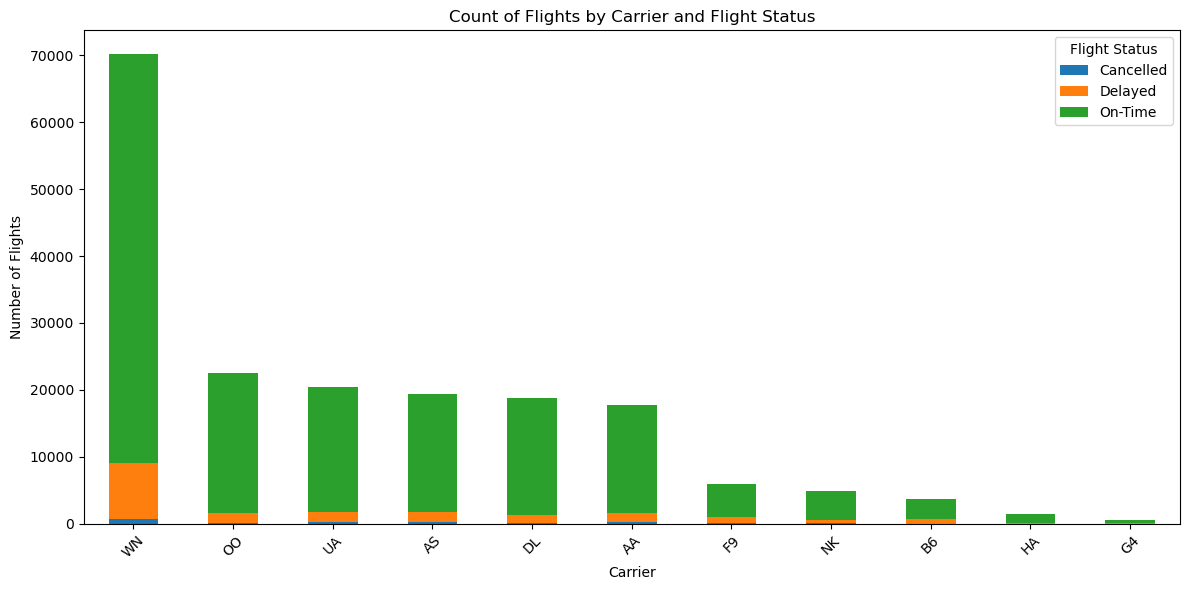

In [17]:
# explore flight carriers and statuses
# get the count of flights by carrier and status
carrier_status_counts = raw_eda_df.groupby(['OP_UNIQUE_CARRIER', 'Flight_Status']).size().reset_index()
carrier_status_counts.columns = ['Carrier', 'Flight_Status', 'Count']

# pivot table for plotting
carrier_status_pivot = carrier_status_counts.pivot(index='Carrier', columns='Flight_Status', values='Count').fillna(0)
print(carrier_status_pivot)
# sort by total flight count per carrier
carrier_status_pivot['Total'] = carrier_status_pivot.sum(axis=1)
carrier_status_pivot = carrier_status_pivot.sort_values(by='Total', ascending=False)
carrier_status_pivot = carrier_status_pivot.drop(columns='Total')

# plot stacked bar chart
carrier_status_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Count of Flights by Carrier and Flight Status')
plt.xlabel('Carrier')
plt.ylabel('Number of Flights')
plt.legend(title='Flight Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# noticing mismatch in counts before and after 
# count how many rows have both cancelled and delayed
both_cancelled_and_delayed = raw_eda_df[
    (raw_eda_df['DEP_DEL15'] == 1) & 
    (raw_eda_df['CANCELLED'] == 1)
]

print("Rows where a cancelled flight was also marked as delayed:", len(both_cancelled_and_delayed))

## There are 10 flights that were classified as both cancelled and delayed,
## this accounts for why the counts seem to be off when we examined the counts of the columns previously
## these rows will be classified as cancelled in the processed dataset

Rows where a cancelled flight was also marked as delayed: 10


In [19]:
# one hot encode the carrier column
carrier_dummies = pd.get_dummies(raw_eda_df['OP_UNIQUE_CARRIER'], prefix='Carrier')

# concatenate the carrier dummies with the original dataframe, we are not going to get rid of the extra column just yet.
raw_eda_df = pd.concat([raw_eda_df, carrier_dummies], axis=1)


print(raw_eda_df.head())

      FL_DATE CRS_DEP_TIME  DEP_TIME OP_UNIQUE_CARRIER  OP_CARRIER_FL_NUM  \
0  2023-01-01     06:10:00  06:05:00                DL                977   
1  2023-01-01     06:15:00  06:17:00                DL               2423   
2  2023-01-01     06:15:00  06:44:00                AA               1651   
3  2023-01-01     06:15:00  06:15:00                DL                820   
4  2023-01-01     06:15:00  06:13:00                DL                914   

  DEST  DEP_DEL15  CANCELLED CANCELLATION_CODE  CARRIER_DELAY  ...  \
0  DTW          0          0               NaN              0  ...   
1  SLC          0          0               NaN              0  ...   
2  CLT          1          0               NaN              0  ...   
3  ATL          0          0               NaN              0  ...   
4  MSP          0          0               NaN              0  ...   

   Carrier_AS  Carrier_B6  Carrier_DL  Carrier_F9  Carrier_G4  Carrier_HA  \
0       False       False        True  

### Exploration of Weather Features

In [20]:
# get dtype of weather columns
weather_columns = ['wind_dir_degrees', 'wind_speed_kt', 'visibility_statute_mi', 'temperature_c', 'dewpoint_c', 'altimeter_hpa']
raw_eda_df[weather_columns].dtypes

wind_dir_degrees         float64
wind_speed_kt            float64
visibility_statute_mi    float64
temperature_c            float64
dewpoint_c               float64
altimeter_hpa            float64
dtype: object

In [21]:
# check unique values for wind direction
raw_eda_df['wind_dir_degrees'].unique()     

array([290., 280., 270.,   0., 130., 140.,  nan, 210., 240., 260., 220.,
       160., 120., 150., 170., 190., 180., 200., 250., 350., 340., 320.,
       300., 310., 330.,  20.,  90.,  50., 360.,  10.,  40., 230.,  60.,
        70., 110., 100.,  30.,  80.])

In [22]:
# since 0 and 360 are the same, we will replace 0 with 360
raw_eda_df['wind_dir_degrees'] = raw_eda_df['wind_dir_degrees'].replace(0.0, 360.0)

# Address missing values in wind_dir_degrees to change to integer and address missing values
# Missing values are attributed to what is known as Variable Wind speeds, which are often associated with relatively calm wind speeds which are less than 6 knots
# We will replace these missing values with the mode of the wind_dir_degrees column
# get the mode of wind_dir_degrees
mode_wind_dir = raw_eda_df['wind_dir_degrees'].mode()[0]
print("Mode of wind_dir_degrees:", mode_wind_dir)

# replace missing values with the mode
raw_eda_df['wind_dir_degrees'] = raw_eda_df['wind_dir_degrees'].fillna(mode_wind_dir)

# get the count of missing values in wind_dir_degrees
missing_wind_dir = raw_eda_df['wind_dir_degrees'].isnull().sum()
print("Missing values in wind_dir_degrees:", missing_wind_dir)

Mode of wind_dir_degrees: 360.0
Missing values in wind_dir_degrees: 0


In [23]:
# convert the wind_dir_degrees column to integer
raw_eda_df['wind_dir_degrees'] = raw_eda_df['wind_dir_degrees'].astype(int)

In [24]:
# explore unique values for wind speed
print(raw_eda_df['wind_speed_kt'].unique())

# convert them to integers
raw_eda_df['wind_speed_kt'] = raw_eda_df['wind_speed_kt'].astype(int)

[ 7. 11. 17. 15. 13. 16. 20. 14. 19. 18. 12.  9.  8.  0.  3.  5.  6. 10.
  4. 21. 22.]


In [25]:
# explore unique values for wind gust
print(raw_eda_df['wind_gust_kt'].unique())

# convert them to integers
raw_eda_df['wind_gust_kt'] = raw_eda_df['wind_gust_kt'].astype(int)

[19. 25.  0. 24. 23. 28. 26. 21. 18. 20. 22. 16. 17. 27. 15. 30. 34. 14.
 29. 42. 32. 35. 31. 33.]


In [26]:
# explore unique values for visibility
print(raw_eda_df['visibility_statute_mi'].unique())

[ 6.     3.     9.    10.     8.     4.     2.5    1.5    7.     2.
  5.     1.     1.75   1.25   0.75   0.25   0.5    0.125]


In [27]:
# check temperature unique values
print(raw_eda_df['temperature_c'].unique())

[ 13.3  13.9  14.4  15.   15.6  11.7  12.2  12.8  14.   16.1  16.   16.7
  17.8  17.2   9.4  10.   11.1   8.3   7.8  10.6  18.9  19.4  18.3   8.9
  20.6  21.1  22.2  20.   17.   13.    5.6   6.1   4.4   7.2   5.   21.7
   6.7  24.4  23.3  22.8  12.   23.9  25.6  26.7  26.1  27.2  25.   18.
   0.   19.   21.   27.8  27.   22.   23.   28.9  28.3 -17.8  24.   11.
   3.9  29.4  30.   30.6  31.1  31.7  32.2  32.8  34.4]


In [28]:
# check dewpoint unique values
print(raw_eda_df['dewpoint_c'].unique())

[ 10.    9.4   8.3   8.9   7.8  10.6  11.   11.1  11.7  12.   12.2  13.3
  12.8  13.9  14.   13.   14.4   5.    5.6   6.1   3.3   4.4   2.8   0.6
   2.2   3.9   6.7   7.2   1.1   8.   -2.2  -1.7   1.7  -3.9  -3.3  -6.7
  -6.1  -4.4  -0.6   0.   -5.   -7.8  -7.2  -8.3  -5.6  -2.8  -1.1  -8.9
   7.  -10.6 -12.8 -12.2 -11.7 -13.3   9.    6.   15.   15.6  16.   16.1
  16.7  17.2  17.8  18.3  18.9  17.   18.   19.   19.4  21.1  21.7  22.2
  22.8  20.   20.6  21.  -17.8  10.9  22.  -11.1  -9.4]


In [29]:
# check altimeter unique values
print(raw_eda_df['altimeter_hpa'].unique())

[29.82 29.83 29.84 29.86 29.88 29.85 29.9  29.91 29.97 29.98 30.01 30.03
 30.05 30.02 30.04 30.07 30.08 30.09 30.06 30.1  30.11 30.12 30.14 30.15
 30.16 30.17 30.13 30.19 30.21 30.23 30.24 30.25 30.22 30.2  30.18 30.28
 30.   29.99 29.95 29.94 29.93 29.92 29.89 29.96 29.87 29.79 29.8  29.81
 30.26 30.27 30.3  30.31 30.33 30.34 30.29 30.35 30.36 30.32 29.78 29.77
 29.76 29.61 29.58 29.56 29.54 29.51 29.49 29.46 29.45 29.47 29.48 29.52
 29.59 29.63 29.64 29.71 29.72 29.75 29.74 29.73 29.7  29.68 29.67 29.69]


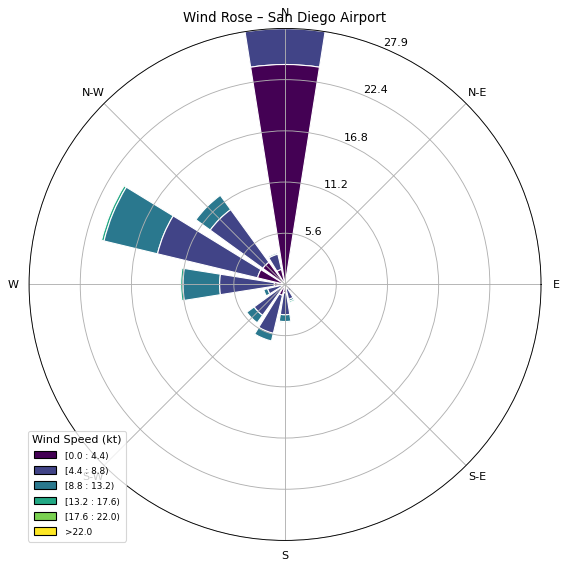

In [30]:
# develop a windrose visualization to visualize the most common direction and speeds.
from windrose import WindroseAxes

wind_rose_df = raw_eda_df[['wind_dir_degrees', 'wind_speed_kt']]

ax = WindroseAxes.from_ax()
ax.bar(
    wind_rose_df['wind_dir_degrees'],
    wind_rose_df['wind_speed_kt'],
    normed=True,
    opening=0.8,
    edgecolor='white'
)
ax.set_title('Wind Rose – San Diego Airport')
ax.set_legend(title="Wind Speed (kt)")
plt.show()

## Destination Exploration

In [31]:
# check the unique values for DEST
print(raw_eda_df['DEST'].unique())

['DTW' 'SLC' 'CLT' 'ATL' 'MSP' 'LAS' 'PHX' 'DFW' 'DEN' 'SMF' 'SJC' 'OAK'
 'LAX' 'SFO' 'ORD' 'PHL' 'AUS' 'JFK' 'SEA' 'EWR' 'DAL' 'HNL' 'LIH' 'IAH'
 'MCO' 'BNA' 'IAD' 'OGG' 'BOS' 'RDM' 'MDW' 'ELP' 'RNO' 'HOU' 'HDN' 'KOA'
 'SAT' 'MRY' 'MCI' 'FLL' 'ABQ' 'BOI' 'PDX' 'SBP' 'TUS' 'STS' 'BWI' 'STL'
 'FAT' 'GEG' 'MIA' 'MSY' 'COS' 'DSM' 'PVU' 'BZN' 'JAC' 'EUG' 'FSD' 'BLI'
 'AZA' 'PSC' 'IDA' 'CLE' 'MFR' 'IND' 'FCA' 'MSO' 'TPA' 'PAE' 'ANC' 'PIT'
 'CMH' 'MKE' 'EGE']


In [32]:
# map airport codes to region
region_map = {
    # West
    'LAX': 'West', 'SFO': 'West', 'OAK': 'West', 'SJC': 'West', 'SMF': 'West',
    'SBP': 'West', 'STS': 'West', 'SAN': 'West', 'FAT': 'West', 'MRY': 'West',
    'BOI': 'West', 'PDX': 'West', 'RDM': 'West', 'EUG': 'West', 'BLI': 'West',
    'PAE': 'West', 'RNO': 'West', 'PSC': 'West', 'SMF': 'West', 'SEA': 'West',
    'GEG': 'West', 'MFR': 'West', 

    # Mountain
    'SLC': 'Mountain', 'DEN': 'Mountain', 'COS': 'Mountain', 'HDN': 'Mountain',
    'ABQ': 'Mountain', 'BZN': 'Mountain', 'JAC': 'Mountain', 'IDA': 'Mountain',
    'MSO': 'Mountain', 'FCA': 'Mountain', 'PVU': 'Mountain', 'EGE': 'Mountain',

    # Southwest
    'PHX': 'Southwest', 'TUS': 'Southwest', 'LAS': 'Southwest', 'AZA': 'Southwest',
    'ELP': 'Southwest',

    # Midwest
    'ORD': 'Midwest', 'MDW': 'Midwest', 'MCI': 'Midwest', 'STL': 'Midwest',
    'DTW': 'Midwest', 'MSP': 'Midwest', 'IND': 'Midwest', 'CMH': 'Midwest',
    'CLE': 'Midwest', 'MKE': 'Midwest', 'DSM': 'Midwest', 'FSD': 'Midwest',

    # South
    'CLT': 'South', 'ATL': 'South', 'BNA': 'South', 'DFW': 'South', 'DAL': 'South', 'AUS': 'South',
    'IAH': 'South', 'HOU': 'South', 'SAT': 'South', 'MSY': 'South', 'MCO': 'South',
    'TPA': 'South', 'FLL': 'South', 'MIA': 'South',

    # Northeast
    'BOS': 'Northeast', 'PHL': 'Northeast', 'JFK': 'Northeast', 'EWR': 'Northeast',
    'PIT': 'Northeast', 'IAD': 'Northeast', 'BWI': 'Northeast',

    # OCONUS will serve as the placeholder for Alaska and Hawaii flights
    # OCONUS refers to Outside Continental United States
    'ANC': 'OCONUS', 'HNL': 'OCONUS', 'KOA': 'OCONUS', 'OGG': 'OCONUS', 'LIH': 'OCONUS',
}
# DEST to region
raw_eda_df['DEST_REGION'] = raw_eda_df['DEST'].map(region_map).fillna('Other')

# results
print(raw_eda_df[['DEST', 'DEST_REGION']].head())

  DEST DEST_REGION
0  DTW     Midwest
1  SLC    Mountain
2  CLT       South
3  ATL       South
4  MSP     Midwest


In [33]:
# One hot encode the DEST_REGION column
dest_region_dummies = pd.get_dummies(raw_eda_df['DEST_REGION'], prefix='Dest_Region')

# concatenate the carrier dummies with the original dataframe, we are not going to get rid of the extra column just yet.
raw_eda_df = pd.concat([raw_eda_df, dest_region_dummies], axis=1)

## Finalize data frame for processed data

In [34]:
processed_df = raw_eda_df.copy()
processed_df = processed_df.drop(columns=['DEP_TIME', 'DEP_DEL15', 'CANCELLED', 'OP_CARRIER_FL_NUM', 'CANCELLATION_CODE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'])

# create the target variable for the model using Flight_Status where if Cancelled or Delayed = 1 and On-time = 0
processed_df['Flight_Status_Binary'] = processed_df['Flight_Status'].apply(
    lambda x: 1 if x in ['Delayed', 'Cancelled'] else 0
)

#print head
print(processed_df.head())

      FL_DATE CRS_DEP_TIME OP_UNIQUE_CARRIER DEST  wind_dir_degrees  \
0  2023-01-01     06:10:00                DL  DTW               290   
1  2023-01-01     06:15:00                DL  SLC               290   
2  2023-01-01     06:15:00                AA  CLT               290   
3  2023-01-01     06:15:00                DL  ATL               290   
4  2023-01-01     06:15:00                DL  MSP               290   

   wind_speed_kt  wind_gust_kt  visibility_statute_mi  temperature_c  \
0              7            19                    6.0           13.3   
1              7            19                    6.0           13.3   
2              7            19                    6.0           13.3   
3              7            19                    6.0           13.3   
4              7            19                    6.0           13.3   

   dewpoint_c  ...  Carrier_WN DEST_REGION  Dest_Region_Midwest  \
0        10.0  ...       False     Midwest                 True   
1     

In [35]:
# save the processed data to a csv file
processed_df.to_csv("processed_data/processed_data.csv", index=False)

## skip this section and only work above on the EDA (this is the failed trying to read in from the database)


#set parameters for athena connection
region_name = "us-east-1"
s3_staging_dir = "s3://group9-ml-proj-raw-data-bucket-grw/queries/"


#establish connection
conn = connect(s3_staging_dir=s3_staging_dir, region_name=region_name)
cursor = conn.cursor()

#query the glue table
query = """
    SELECT * 
    FROM raw_data.raw_merged_data_csv
    """


#read the query into a pandas dataframe
raw_df = pd.read_sql(query, conn)

#print head of the df
raw_df.head()

In [1]:
%%html
<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>